In [1]:
# Cell 1 — Импорты
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


In [2]:
# Cell 2 — Настройки

CLEAN_DIR = Path("cleaned_data")

FILES = {
    "1 open eyes_clean.edf":               "1 Открытые\n(эталон)",
    "2 closed eyes_clean.edf":             "2 Закрытые\n(эталон)",
    "3 2026.01.24-16.16.21.085_clean.edf": "3 Слабый поток\nоткрытые",
    "4 2026.01.24-16.18.47.499_clean.edf": "4 Слабый поток\nзакрытые",
    "5 2026.01.24-16.38.37.757_clean.edf": "5 Мощный поток\nзакрытые",
    "6 2026.01.24-16.41.01.794_clean.edf": "6 Мощный поток\nоткрытые",
    "7 2026.01.24-16.53.06.041_clean.edf": "7 Изнутри\n(16 сек)",
    "8 2026.01.24-17.03.42.427_clean.edf": "8 Медитация\nвнутрь себя",
    "9 2026.01.24-17.05.59.615_clean.edf": "9 Исчезновение\nощущения себя",
}

CHANNELS = ["O1", "T3", "Fp1", "Fp2", "T4", "O2"]

BANDS = {
    "Delta\n1–4 Гц":   (1, 4),
    "Theta\n4–8 Гц":   (4, 8),
    "Alpha\n8–13 Гц":  (8, 13),
    "Beta\n13–30 Гц":  (13, 30),
    "Gamma\n30–48 Гц": (30, 48),
}


In [3]:
# Cell 3 — Функция расчета мощностей по полосам

def compute_band_powers(raw, channels, bands):
    """
    Для каждого канала считает спектр методом Уэлча,
    затем усредняет по каналам и возвращает мощность
    в каждой полосе в процентах от суммарной мощности.
    """
    sfreq = raw.info["sfreq"]
    all_psds = []

    for ch in channels:
        try:
            signal = raw.copy().pick([ch]).get_data()[0]
        except Exception:
            continue

        freqs, psd = welch(
            signal,
            fs=sfreq,
            nperseg=min(len(signal), int(sfreq * 4))
        )
        all_psds.append((freqs, psd))

    if not all_psds:
        return {b: 0.0 for b in bands}

    freqs = all_psds[0][0]
    mean_psd = np.mean([p for _, p in all_psds], axis=0)

    powers = {}
    for band_name, (fmin, fmax) in bands.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        powers[band_name] = np.trapezoid(mean_psd[mask], freqs[mask])

    total = sum(powers.values())
    if total > 0:
        powers = {k: v / total * 100 for k, v in powers.items()}

    return powers


In [4]:
# Cell 4 — Загрузка данных и расчет матрицы

print("Загружаю файлы...")
data = {}

for filename, label in FILES.items():
    path = CLEAN_DIR / filename
    if not path.exists():
        print(f"  [!] Не найден: {filename} — пропускаю")
        continue

    raw = mne.io.read_raw_edf(path, preload=True, verbose="ERROR")
    data[label] = compute_band_powers(raw, CHANNELS, BANDS)
    print(f"  ✓ {label.replace(chr(10), ' ')}")

if not data:
    raise FileNotFoundError("Ни один файл не найден. Проверь путь CLEAN_DIR.")

labels = list(data.keys())
band_names = list(BANDS.keys())
n_states = len(labels)
n_bands = len(band_names)

matrix = np.array([[data[lbl][b] for b in band_names] for lbl in labels])

print("Готово.")
print("Количество состояний:", n_states)


Загружаю файлы...
  ✓ 1 Открытые (эталон)
  ✓ 2 Закрытые (эталон)
  ✓ 3 Слабый поток открытые
  ✓ 4 Слабый поток закрытые
  ✓ 5 Мощный поток закрытые
  ✓ 6 Мощный поток открытые
  ✓ 7 Изнутри (16 сек)
  ✓ 8 Медитация внутрь себя
  ✓ 9 Исчезновение ощущения себя
Готово.
Количество состояний: 9


In [5]:
# Cell 5 — Цвета

STATE_COLORS = [
    "#888888",  # 1 эталон открытые
    "#555555",  # 2 эталон закрытые
    "#4C9BE8",  # 3
    "#3A7FD4",  # 4
    "#E8834C",  # 5
    "#D4673A",  # 6
    "#6DC06A",  # 7
    "#4DA84A",  # 8
    "#A855C8",  # 9
]

colors = STATE_COLORS[:n_states]


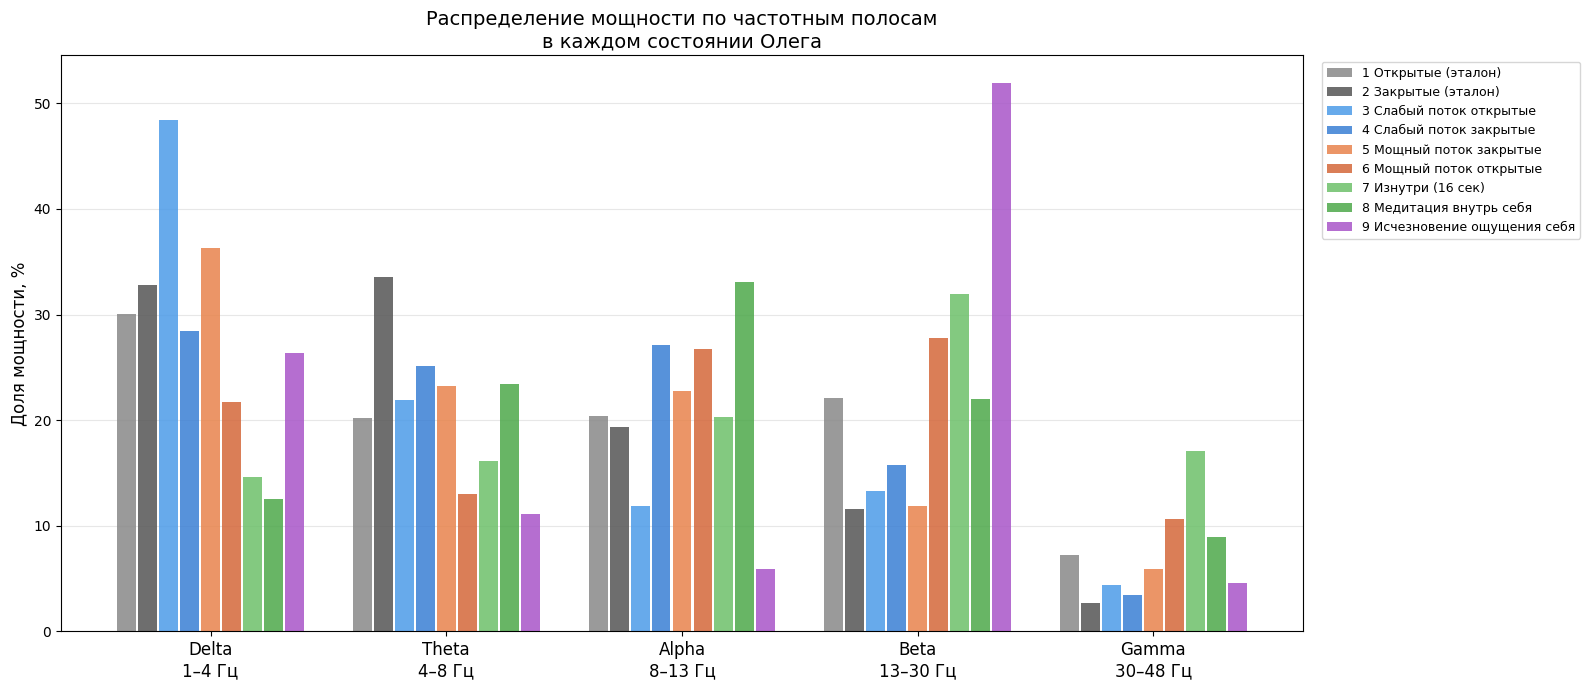

Сохранено: oleg_bands_bar.png


In [6]:
# Cell 6 — Столбчатая диаграмма

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(n_bands)
width = 0.8 / n_states

for i, (lbl, col) in enumerate(zip(labels, colors)):
    offset = (i - n_states / 2 + 0.5) * width
    ax.bar(
        x + offset,
        matrix[i],
        width=width * 0.9,
        color=col,
        alpha=0.85,
        label=lbl.replace("\n", " ")
    )

ax.set_xticks(x)
ax.set_xticklabels(band_names, fontsize=12)
ax.set_ylabel("Доля мощности, %", fontsize=12)
ax.set_title(
    "Распределение мощности по частотным полосам\nв каждом состоянии Олега",
    fontsize=14
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("oleg_bands_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено: oleg_bands_bar.png")


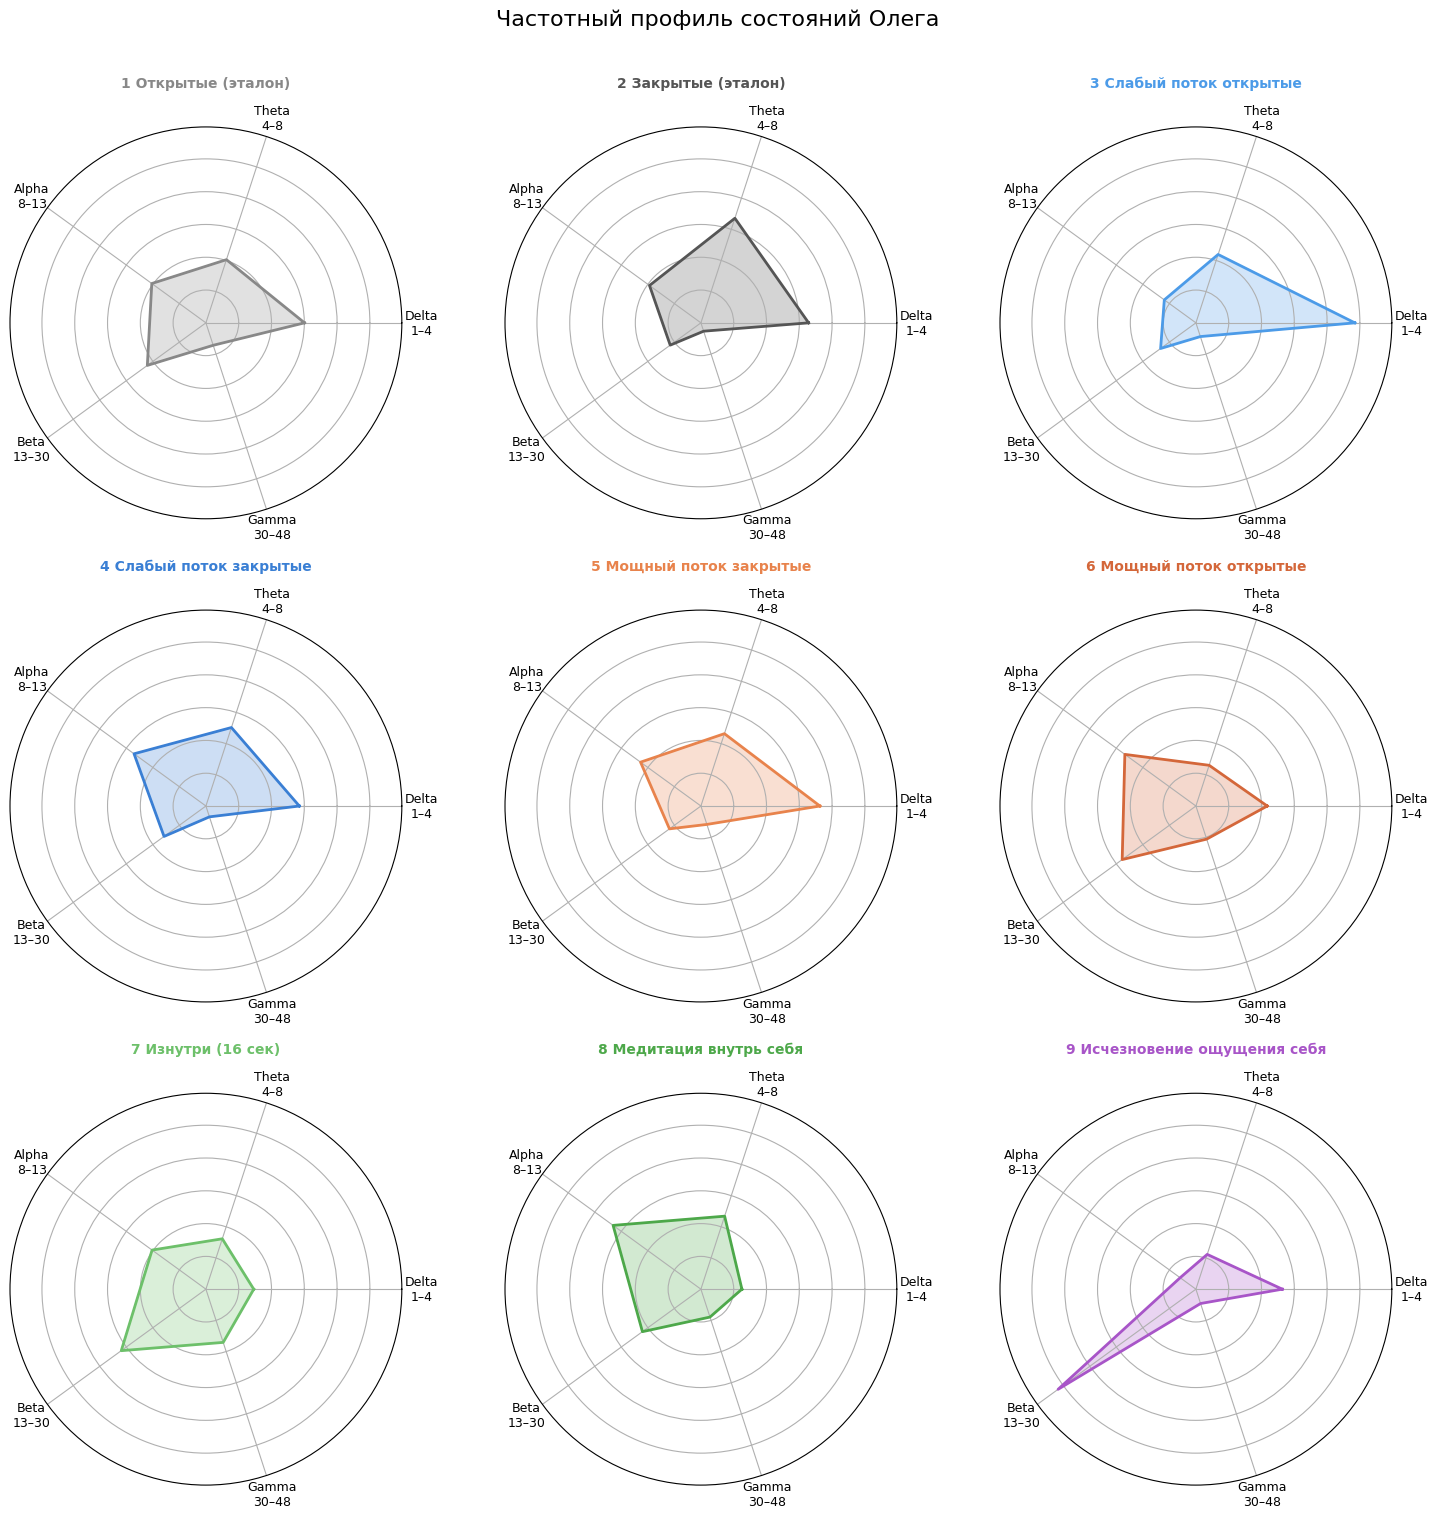

Сохранено: oleg_radar.png


In [7]:
# Cell 7 — Радарная диаграмма

angles = np.linspace(0, 2 * np.pi, n_bands, endpoint=False).tolist()
angles += angles[:1]

radar_labels = [
    "Delta\n1–4",
    "Theta\n4–8",
    "Alpha\n8–13",
    "Beta\n13–30",
    "Gamma\n30–48"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (lbl, col) in enumerate(zip(labels, colors)):
    ax = axes[i]
    values = matrix[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=col, linewidth=2)
    ax.fill(angles, values, color=col, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_title(
        lbl.replace("\n", " "),
        fontsize=10,
        pad=12,
        color=col,
        fontweight="bold"
    )

    ax.set_yticklabels([])
    ax.set_ylim(0, matrix.max() * 1.15)

for j in range(n_states, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Частотный профиль состояний Олега", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("oleg_radar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено: oleg_radar.png")


In [8]:
# Cell 8 — Таблица Alpha/Beta

print("── Alpha/Beta по состояниям ──")
print(f"{'Состояние':<35} {'Alpha/Beta':>10}")
print("─" * 47)

for lbl in labels:
    a = data[lbl]["Alpha\n8–13 Гц"]
    b = data[lbl]["Beta\n13–30 Гц"]
    ratio = a / b if b > 0 else 0
    marker = " ◄" if ratio < 0.3 else ""
    print(f"{lbl.replace(chr(10), ' '):<35} {ratio:>10.3f}{marker}")

print("\n◄ = необычно низкий alpha/beta (сильное отличие от состояния покоя)")


── Alpha/Beta по состояниям ──
Состояние                           Alpha/Beta
───────────────────────────────────────────────
1 Открытые (эталон)                      0.924
2 Закрытые (эталон)                      1.675
3 Слабый поток открытые                  0.895
4 Слабый поток закрытые                  1.717
5 Мощный поток закрытые                  1.919
6 Мощный поток открытые                  0.964
7 Изнутри (16 сек)                       0.636
8 Медитация внутрь себя                  1.501
9 Исчезновение ощущения себя             0.114 ◄

◄ = необычно низкий alpha/beta (сильное отличие от состояния покоя)
